In [1]:
import datetime
import os
import numpy as np
import pandas as pd
import torch
import torchvision.models as models
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.nn import functional as F

%matplotlib inline
from d2l import torch as d2l
from tqdm import tqdm
import torchvision


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 自动检测设

In [2]:
def evaluate_accuracy_gpu(net, data_iter, device=None): #@save
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = d2l.Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [3]:
#保存模型参数
def load_checkpoint(model, optimizer, scheduler=None, path='RetNet_last_model.pth'):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if scheduler and checkpoint['scheduler_state_dict']:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1  # 从下一epoch开始
    print(f"Resuming from epoch {start_epoch}")  #打印之前已经训练了多少epoch
    return start_epoch

In [4]:
#@save
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    #net.apply(init_weights)
    
    print('training on', device)
    net.to(device)
    #optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=0.05)  # L2正则化
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
    
    #根据保存的参数继续训练
    start_epoch=0
    start_epoch = load_checkpoint(net, optimizer)
    
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    test_acc_best=0
    corresponding_train_acc=0
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            # 更新学习率
            scheduler.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        if test_acc > test_acc_best:
            test_acc_best=test_acc
            corresponding_train_acc=train_acc
            #保存test acc最好的模型参数
            checkpoint = {
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'test_acc_best': test_acc_best,
                'epoch': epoch+start_epoch
            }
            torch.save(checkpoint, 'RetNet_best_model.pth')
        #保存最后一次训练参数模型
        checkpoint = {
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch+start_epoch,
            'last_test_acc': test_acc
        }
        torch.save(checkpoint, 'RetNet_last_model.pth')
            
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}\n' 
          f'best test acc {test_acc_best:.3f},corresponding train acc {corresponding_train_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

In [5]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

# 数据预处理配置
transform = transforms.Compose([
    transforms.Resize((224, 224)),       # 统一尺寸
    transforms.RandomHorizontalFlip(p=0.5),  # 以50%的概率水平翻转图像
    transforms.ColorJitter(
        brightness=0.2,  # 亮度调整因子（范围：[1-0.2, 1+0.2]）
        contrast=0.2,    # 对比度调整因子（范围：[1-0.2, 1+0.2]）
        saturation=0.2,  # 饱和度调整因子（范围：[1-0.2, 1+0.2]）
        hue=0.1          # 色调偏移范围（范围：[-0.1, 0.1]）
    ),
    transforms.ToTensor(),              # 转为Tensor
])

# 在数据加载部分添加更强的数据增强（以图像分类为例）
# transform = transforms.Compose([
#     transforms.RandomResizedCrop(224),  # 随机裁剪缩放
#     transforms.RandomHorizontalFlip(p=0.5),  # 以50%的概率水平翻转图像
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2,hue=0.1),  # 颜色抖动
#     transforms.RandomRotation(15),  # 随机旋转
#     transforms.RandomAffine(degrees=0, shear=0.2),  # 仿射变换
#     transforms.ToTensor() # 转为Tensor
# ])

# 加载完整数据集（假设目录结构为`./data/NC`和`./data/SLE`）
full_dataset = datasets.ImageFolder(
    root='E:/LazySheep/Desktop/total/T_test',
    transform=transform
)

# 划分训练集和测试集（8:2比例）
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # 固定随机种子保证可复现
)

# 创建DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=True  # GPU训练时加速数据加载
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=4
)

In [6]:
# 直接加载除fc层外的所有预训练权重
Resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT).to(device)  # 初始为1000类
Resnet.fc = torch.nn.Linear(2048, 2).to(device)       # 修改输出层

# 重新训练fc层（其他层参数冻结）
for param in Resnet.parameters():
    param.requires_grad = False
Resnet.fc.requires_grad = True


# 验证设备一致性
print(next(Resnet.parameters()).device)  # 应输出cuda:0

cuda:0


In [7]:
from torchsummary import summary
summary(Resnet, input_size=(3, 224, 224))  # 输入尺寸需与实际匹配

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [8]:
# 加载参数文件
checkpoint = torch.load('RetNet_best_model.pth', map_location=torch.device('cuda'))  # 指定设备

# 严格模式加载（推荐默认）
Resnet.load_state_dict(checkpoint['model_state_dict'], strict=True)  
Resnet.eval()  # 关闭Dropout/BatchNorm的训练行为

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [14]:
Resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
# 修改最后的全连接层，适应分类任务
import torch.optim as optim
# 使用Adam优化器
optimizer = optim.Adam(Resnet.parameters(), lr=1e-4, weight_decay=1e-5)
# 使用学习率衰减策略
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)
num_ftrs = Resnet.fc.in_features # 获取全连接层的输入特征数
Resnet.fc = nn.Linear(num_ftrs, 2)

loss 0.116, train acc 0.983, test acc 0.867
best test acc 0.894,corresponding train acc 0.979
177.6 examples/sec on cuda:0


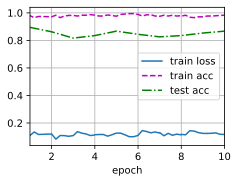

In [29]:
lr = 1e-6
num_epoch = 10
# 可以选用不同的网络
train_ch6(Resnet, train_loader, test_loader, num_epoch, lr, d2l.try_gpu())

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, 
    roc_auc_score, f1_score, matthews_corrcoef, log_loss,
    confusion_matrix, classification_report
)

def evaluate_medical_model(model, test_loader, device, num_classes=2, alpha=0.05, n_bootstraps=1000):
    """
    增强版医疗模型综合评估函数
    包含ROC/PR曲线可视化、置信区间和p值计算
    特别强化敏感性和特异性指标，适用于SLE病例分类
    
    参数:
        model: 训练好的PyTorch模型
        test_loader: 测试数据加载器
        device: 计算设备 (cuda/cpu)
        num_classes: 分类数 (默认2)
        alpha: 置信水平 (默认0.05)
        n_bootstraps: Bootstrap抽样次数 (默认1000)
        
    返回:
        包含所有评估指标的字典
    """
    model.eval()
    metrics = {
        'total_correct': 0,
        'total_samples': 0,
        'pos_correct': 0,
        'neg_correct': 0,
        'pos_samples': 0,
        'neg_samples': 0,
        'all_labels': [],
        'all_probs': [],
        'all_preds': []
    }

    # 数据收集阶段
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            # 统计基础指标
            metrics['total_correct'] += (preds == labels).sum().item()
            metrics['total_samples'] += labels.size(0)
            
            # 正负样本统计
            pos_mask = (labels == 1)
            neg_mask = (labels == 0)
            metrics['pos_correct'] += (preds[pos_mask] == labels[pos_mask]).sum().item()
            metrics['neg_correct'] += (preds[neg_mask] == labels[neg_mask]).sum().item()
            metrics['pos_samples'] += pos_mask.sum().item()
            metrics['neg_samples'] += neg_mask.sum().item()
            
            # 收集评估所需数据
            metrics['all_labels'].extend(labels.cpu().numpy())
            metrics['all_probs'].extend(probs[:, 1].cpu().numpy())  # 取正类概率
            metrics['all_preds'].extend(preds.cpu().numpy())

    # 转换为numpy数组
    y_true = np.array(metrics['all_labels'])
    y_pred = np.array(metrics['all_preds'])
    y_probs = np.array(metrics['all_probs'])
    
    # 计算混淆矩阵元素
    TP = metrics['pos_correct']
    TN = metrics['neg_correct']
    FP = metrics['neg_samples'] - TN
    FN = metrics['pos_samples'] - TP
    
    # 构建混淆矩阵
    cm = np.array([[TN, FP], [FN, TP]])
    
    # ================== 计算核心医疗指标 ==================
    final_metrics = {
        'accuracy': (TP + TN) / (TP + TN + FP + FN),
        'sensitivity': TP / (TP + FN) if (TP + FN) > 0 else 0,  # 召回率/敏感性
        'specificity': TN / (TN + FP) if (TN + FP) > 0 else 0,  # 特异性
        'precision': TP / (TP + FP) if (TP + FP) > 0 else 0,
        'f1_score': f1_score(y_true, y_pred),
        'auc_roc': roc_auc_score(y_true, y_probs),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'log_loss': log_loss(y_true, y_probs),
        'fpr': FP / (FP + TN) if (FP + TN) > 0 else 0,  # 假阳性率
        'fnr': FN / (FN + TP) if (FN + TP) > 0 else 0,  # 假阴性率
        'confusion_matrix': cm,
        'confusion_matrix_elements': {'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN}
    }
    
    # ================== 统计显著性分析 ==================
    # 1. 计算准确率的p值（二项检验）
    baseline_acc = max(metrics['pos_samples'], metrics['neg_samples']) / metrics['total_samples']
    
    # 使用binomtest替代已弃用的binom_test
    binomial_test = stats.binomtest(
        k=metrics['total_correct'],
        n=metrics['total_samples'],
        p=baseline_acc,
        alternative='greater'
    )
    p_value_acc = binomial_test.pvalue
    
    # 2. Bootstrap计算置信区间
    def bootstrap_metric(metric_func, labels, probs, n_bootstraps=1000):
        values = []
        for _ in range(n_bootstraps):
            # 重抽样
            idx = np.random.choice(len(labels), len(labels), replace=True)
            resampled_labels = labels[idx]
            resampled_probs = probs[idx]
            
            # 计算指标
            if metric_func == roc_auc_score:
                if len(np.unique(resampled_labels)) < 2:
                    values.append(0.5)
                else:
                    values.append(metric_func(resampled_labels, resampled_probs))
            else:
                preds = (resampled_probs > 0.5).astype(int)
                values.append(metric_func(resampled_labels, preds))
        
        # 计算置信区间
        lower = np.percentile(values, 100 * alpha/2)
        upper = np.percentile(values, 100 * (1 - alpha/2))
        return (lower, upper)
    
    # 3. 关键指标置信区间计算
    ci_auc = bootstrap_metric(roc_auc_score, y_true, y_probs, n_bootstraps)
    ci_f1 = bootstrap_metric(f1_score, y_true, y_probs, n_bootstraps)
    ci_sensitivity = bootstrap_metric(
        lambda y_true, y_pred: np.sum((y_true == 1) & (y_pred == 1)) / np.sum(y_true == 1),
        y_true, (y_probs > 0.5).astype(int), n_bootstraps
    )
    
    # 添加统计指标
    final_metrics.update({
        'p_value': {
            'acc_vs_baseline': p_value_acc,
        },
        'confidence_interval': {
            'auc': ci_auc,
            'f1': ci_f1,
            'sensitivity': ci_sensitivity,
        },
        'statistical_significance': {
            'baseline_accuracy': baseline_acc,
            'alpha': alpha,
            'bootstrap_rounds': n_bootstraps
        }
    })
    
    # ================== 可视化部分 ==================
    plt.figure(figsize=(15, 5))
    
    # 1. ROC曲线
    plt.subplot(131)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")

    # 2. PR曲线（医疗重点）
    plt.subplot(132)
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="upper right")

    # 3. 混淆矩阵热力图
    plt.subplot(133)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['NC', 'SLE'], 
                yticklabels=['NC', 'SLE'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')

    plt.tight_layout()
    plt.savefig('medical_model_evaluation.png', dpi=300)
    plt.show()

    # 添加分类报告
    print("\n" + "="*60)
    print(classification_report(y_true, y_pred, target_names=['NC', 'SLE']))
    print("="*60 + "\n")
    
    return final_metrics

In [31]:
# 加载参数文件
checkpoint = torch.load('RetNet_best_model.pth', map_location=device)  # 指定设备

# 严格模式加载（推荐默认）
Resnet.load_state_dict(checkpoint['model_state_dict'], strict=True)  
Resnet.eval()  # 关闭Dropout/BatchNorm的训练行为
# 确保模型与数据在同一设备

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

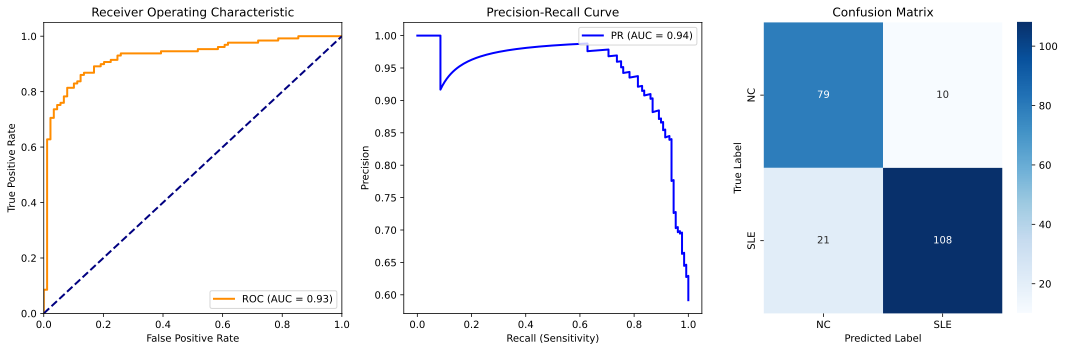


              precision    recall  f1-score   support

          NC       0.79      0.89      0.84        89
         SLE       0.92      0.84      0.87       129

    accuracy                           0.86       218
   macro avg       0.85      0.86      0.86       218
weighted avg       0.86      0.86      0.86       218


敏感性: 0.8372 [95%CI: 0.776-0.897]
特异性: 0.8876
F1分数: 0.8745
精确率：0.9153 | 召回率：0.8372
MCC：0.7150 | 对数损失：0.3514
AUC-ROC: 0.9257 [95%CI: 0.884-0.954]
模型优于基准的统计显著性: p=0.0000


In [45]:
Resnet = Resnet.to(device)  # 将模型权重转移到GPU
# 执行评估
metrics = evaluate_medical_model(
    Resnet, 
    test_loader, 
    device,
    n_bootstraps=200  # 推荐小样本使用更多抽样
)

# 输出关键医疗指标
print(f"敏感性: {metrics['sensitivity']:.4f} [95%CI: {metrics['confidence_interval']['sensitivity'][0]:.3f}-{metrics['confidence_interval']['sensitivity'][1]:.3f}]")
print(f"特异性: {metrics['specificity']:.4f}")
print(f"F1分数: {metrics['f1_score']:.4f}")
print(f"精确率：{metrics['precision']:.4f} | 召回率：{metrics['sensitivity']:.4f}")
print(f"MCC：{metrics['mcc']:.4f} | 对数损失：{metrics['log_loss']:.4f}") #MCC越接近1越好
print(f"AUC-ROC: {metrics['auc_roc']:.4f} [95%CI: {metrics['confidence_interval']['auc'][0]:.3f}-{metrics['confidence_interval']['auc'][1]:.3f}]")
print(f"模型优于基准的统计显著性: p={metrics['p_value']['acc_vs_baseline']:.4f}")